In [1]:
import pandas as pd

In [2]:
pd.set_option('display.max_columns', None)


In [3]:
gt_ip = pd.read_csv('../data/raw/ehn_gt_inpatient_20251223000.csv')
gt_op = pd.read_csv('../data/raw/ehn_gt_outpatient_20251223000.csv')

In [4]:
gt_op.eventdate.max()

'2024-12-31'

In [5]:
risks = pd.read_csv('../data/raw/2024 Totals and Risk.csv')

/var/folders/v8/s4lwxw8s6wxbkhy0gqkmypnc0000gn/T/ipykernel_4237/453277569.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  risks = pd.read_csv('../data/raw/2024 Totals and Risk.csv')


In [6]:
gt_ip.head()

,admitdate,dischargedate,deid_personid,planpayer,patient_city,patient_state,patient_zip,pcpnpi,pcpname,ehn_vs_non,employed_vs_independent,ehn_practice,lhn,entity,cost,paiddate,placeofservice,placeofservicedescription,primary_cpt,cptdescription,primary_icd,icddescription,servicing_prov,servicing_specialty,rptgrouper,servicefacility,servicefacilitynpi,readmission,readmission60,readmission90,followup7dayind,followup30daytcoc,dischargedisposition
0,2024-12-22,2024-12-29,56a053a2c5f5a16146246c8cd206b15f,Emory Anthem Commercial,BUFORD,GA,30519,Unknown,UNKNOWN,Unknown,Unknown,Unknown,Unknown,Unknown,304.81,2025-01-09,55,Residential Substance Abuse Treatment Facility,86480,TB CELL MEDIATED ANTIGN RESPNSE GAMMA INTERFERON,F13.20,"Sedative, hypnotic or anxiolytic dependence, u...",1.033750e+09,Clinical Medical Laboratory,IP BEHAVIORAL HEALTH,"SUNRISE DETOX ALPHARETTA, LLC",1.427441e+09,1,1,1,1,218.36,HOME
1,2024-11-30,2024-12-13,282bfaa0946165ec48dd67c64bd43a67,Emory Anthem Commercial,UNION CITY,GA,30291,Unknown,UNKNOWN,Unknown,Unknown,Unknown,Unknown,Unknown,217605.94,2025-01-30,21,Inpatient Hospital,88350,IMMUNOFLUORESCENCE PR SPEC EA ADD SINGL ANTB STN,C83.38,"Diffuse large B-cell lymphoma, lymph nodes of ...",1.699084e+09,Pathology,IP SURGICAL (ADULT),"PAULDING MEDICAL CENTER, INC.",1.457329e+09,0,0,0,0,862755.42,HOME
2,2024-12-04,2024-12-16,72991e18eaf8a5cf2ccad525370c647f,Emory MSSP,LILBURN,GEORGIA,30047,1194091025,"GROSE, LEE",EHN,EHN Employed,Emory at Snellville - Oak Road,EDH,ESA,9172.07,2025-01-17,31,Skilled Nursing Facility,99306,INITIAL NURSING FACILITY CARE HI MDM 50 MINUTES,G93.41,Metabolic encephalopathy,1.104356e+09,Nurse Practitioner,IP SNF,"ENGLAND ASSOCIATES, LP",1.144530e+09,0,0,0,1,3814.60,HOME
3,2024-11-30,2024-12-04,72991e18eaf8a5cf2ccad525370c647f,Emory MSSP,LILBURN,GEORGIA,30047,1194091025,"GROSE, LEE",EHN,EHN Employed,Emory at Snellville - Oak Road,EDH,ESA,11803.04,2024-12-13,21,Inpatient Hospital,99239,HOSPITAL IP/OBS DISCHARGE DAY MGMT > 30 MIN,U07.1,COVID-19,1.245736e+09,Internal Medicine,IP MEDICAL (ADULT),"EASTSIDE MEDICAL CENTER, LLC",1.467406e+09,0,0,0,0,13180.36,IP SNF
4,2024-05-13,2024-05-16,503d9c68c71212bda9697f48ee3a5580,Emory Anthem Commercial,VILLA RICA,GA,30180,Unknown,UNKNOWN,Unknown,Unknown,Unknown,Unknown,Unknown,25410.13,2024-06-06,21,Inpatient Hospital,59400,OB CARE ANTEPARTUM VAG DLVR & POSTPARTUM,O99.824,Streptococcus B carrier state complicating chi...,1.023302e+09,Obstetrics & Gynecology,IP SNF,"TANNER MEDICAL CENTER, INC",1.801884e+09,0,0,0,1,8141.20,HOME


In [7]:
gt_op.columns

Index(['eventdate', 'deid_personid', 'planpayer', 'patient_city',
       'patient_state', 'patient_zip', 'pcpnpi', 'pcpname', 'ehn_vs_non',
       'employed_vs_independent', 'ehn_practice', 'lhn', 'entity', 'cost',
       'paiddate', 'placeofservice', 'placeofservicedescription',
       'primary_cpt', 'cptdescription', 'primary_icd', 'icddescription',
       'servicing_prov', 'servicing_specialty', 'rptgrouper',
       'servicing_practice', 'servicing_lhn', 'servicing_entity'],
      dtype='object')

In [8]:
risks.columns

Index(['deid_personid', 'membermonths', 'payertype', 'city', 'state', 'zip',
       'pcpnpi', 'pcpname', 'ehn_vs_non', 'employed_vs_independent',
       'ehn_practice', 'lhn', 'entity', 'riskhcctotalrisk', 'riskhccclosed',
       'chronicconditionasthmaind', 'chronicconditionesrdind',
       'chronicconditionhfind', 'chronicconditioncrfind',
       'chronicconditionhypertensionind', 'chronicconditioncancerind',
       'chronicconditioncopdind', 'chronicconditiondiabetesind', ' costtotal ',
       'countip', ' costip ', 'ipreadmit', 'followup7daypcp', 'countop',
       ' costop ', 'counted', ' costed ', 'countavoidableed', 'countretailrx',
       ' costretailrx ', 'lastvisitdate', 'lastvisitfacilityname'],
      dtype='object')

In [9]:
risks.head()

,deid_personid,membermonths,payertype,city,state,zip,pcpnpi,pcpname,ehn_vs_non,employed_vs_independent,ehn_practice,lhn,entity,riskhcctotalrisk,riskhccclosed,chronicconditionasthmaind,chronicconditionesrdind,chronicconditionhfind,chronicconditioncrfind,chronicconditionhypertensionind,chronicconditioncancerind,chronicconditioncopdind,chronicconditiondiabetesind,costtotal,countip,costip,ipreadmit,followup7daypcp,countop,costop,counted,costed,countavoidableed,countretailrx,costretailrx,lastvisitdate,lastvisitfacilityname
0,e90f424239154322af8f015e1f88bf69,2.0,MA,ELLENWOOD,GA,30294,1376625053,"ARMSTRONG, CHANDRA",EHN,EHN Independent,"Chandra Britt Armstrong MD, LLC dba Dekalb Fam...",EDH,PRIVATE,3.017,3.017,0,0,1,1,1,0,0,1,$(1.02),0,$-,0,0,0,$-,0,$-,0,4,$(1.02),NaN,NaN
1,649c4ca9a7d14e26361c3cb41e6d871d,5.0,Comm,CUMMING,GA,30041,Unknown,UNKNOWN,Unknown,Unknown,Unknown,Unknown,Unknown,0.224,0.224,0,0,0,0,0,0,0,0,$-,0,$-,0,0,10,$-,0,$-,0,0,$-,12/3/2024,NaN
2,db041b79ea79d30fd6ef69802f3ff818,12.0,Comm,AUSTELL,GA,30168,1053428540,"NWOSU, OGUCHI",EHN,EHN Employed,Emory at Dunwoody - Family Medicine,EUH,EC,0.122,0.122,0,0,0,0,0,0,0,0,$-,0,$-,0,0,3,$-,0,$-,0,0,$-,3/26/2024,NaN
3,932164ff1a357d3df333b56e67b77fa0,3.0,Comm,ATLANTA,GA,30340,1215011663,"CARR, ROGER",EHN,EHN Independent,"Southeast Medical Group, Fayetteville",SC,PRIVATE,0.285,0.285,1,0,0,0,0,0,0,0,$-,0,$-,0,0,0,$-,0,$-,0,0,$-,NaN,NaN
4,48858fec3d5287d5ba456465079f2a32,12.0,MA,LITHONIA,GA,30058,1598897530,"WHITE-WILLIAMS, DOROTHY",EHN,EHN Independent,"Greater Atlanta Family Healthcare, LLC",EDH,PRIVATE,0.324,0.324,0,0,0,0,0,0,0,0,$-,0,$-,0,0,0,$-,0,$-,0,0,$-,NaN,NaN


### Clean cost columns

In [10]:
import re
import numpy as np

for name in ('risks', 'gt_ip', 'gt_op'):
    if name in globals():
        df = globals()[name]
        for col in df.columns:
            if str(col).strip().lower().startswith('cost'):
                s = df[col].astype(str).str.strip()
                # treat explicit "$-" (or variants) as zero
                s = s.replace(r'^\$[\s-]*$', '0', regex=True)
                # detect parentheses indicating negative amounts like $(1.02) or (1.02)
                neg = s.str.match(r'^\(.*\)$')
                # remove dollar, commas, parentheses
                s = s.str.replace(r'[\$\(\),]', '', regex=True).str.strip()
                # empty strings -> NaN
                s = s.replace(r'^\s*$', np.nan, regex=True)
                df[col] = pd.to_numeric(s, errors='coerce')
                if neg.any():
                    df.loc[neg, col] = -df.loc[neg, col]

In [11]:
risks[' costretailrx '].describe()

count    293760.000000
mean       1139.212120
std        8666.521595
min           0.000000
25%           0.000000
50%           0.000000
75%          61.302500
max      701106.650000
Name:  costretailrx , dtype: float64

In [12]:
risks.deid_personid.nunique()

233955

In [13]:
gt_op.deid_personid.nunique()

326485

In [14]:
gt_ip.deid_personid.nunique()

16991

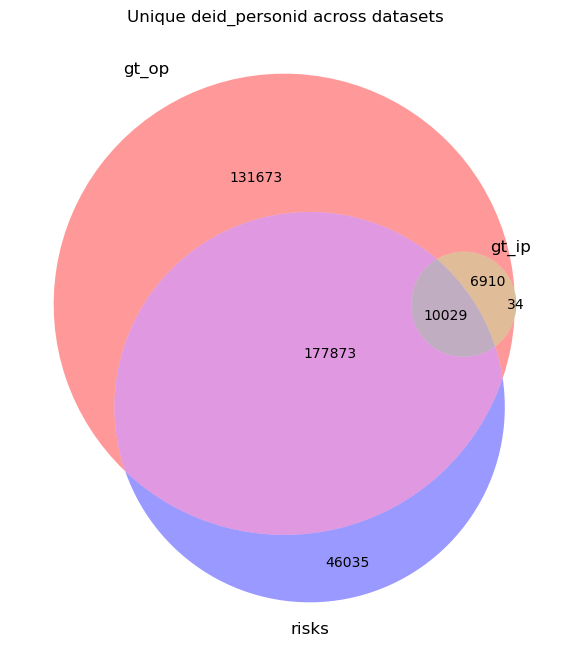

In [16]:
from matplotlib_venn import venn3

import matplotlib.pyplot as plt

# Get unique deid_personid from each dataframe
op_ids = set(gt_op.deid_personid.unique())
ip_ids = set(gt_ip.deid_personid.unique())
risk_ids = set(risks.deid_personid.unique())

# Create Venn diagram
plt.figure(figsize=(10, 8))
venn3([op_ids, ip_ids, risk_ids], set_labels=('gt_op', 'gt_ip', 'risks'))
plt.title('Unique deid_personid across datasets')
plt.show()

In [17]:
gt_ip.cost.describe()

count    2.420600e+04
mean     2.799893e+04
std      6.549394e+04
min     -5.935800e+03
25%      9.195198e+03
50%      1.554266e+04
75%      2.678278e+04
max      3.469864e+06
Name: cost, dtype: float64

In [18]:
gt_ip.primary_icd.unique()

array(['F13.20', 'C83.38', 'G93.41', ..., 'C48.1', 'F19.94', 'Q07.00'],
      shape=(3360,), dtype=object)

In [19]:
# top 20 primary_icd codes
gt_ip.primary_icd.value_counts().head(20)

primary_icd
A41.9      1062
I13.0       435
N17.9       369
I11.0       347
O34.211     318
O48.0       303
I21.4       301
I48.0       219
U07.1       214
F33.2       203
J18.9       202
O13.4       199
F10.20      193
J44.1       178
N39.0       161
M48.062     157
A41.51      156
J96.01      149
I26.99      133
I25.110     130
Name: count, dtype: int64

In [20]:
# total costs for the top 20 primary_icd codes (from gt_ip) in Millions
top20_codes = gt_ip.primary_icd.value_counts().head(20).index
costs_top20 = (gt_ip[gt_ip.primary_icd.isin(top20_codes)]
               .groupby('primary_icd', as_index=False)['cost']
               .sum()
               .sort_values('cost', ascending=False))
costs_top20['cost'] = costs_top20['cost'] / 1e6  # Convert to Millions
costs_top20

,primary_icd,cost
1,A41.9,27.722949
5,I13.0,12.301188
6,I21.4,10.969318
13,M48.062,8.677963
17,O34.211,7.151731
4,I11.0,6.439026
18,O48.0,5.767282
14,N17.9,5.527008
12,J96.01,5.476920
7,I25.110,5.468295


In [21]:
# average cost per event (and per day) for the top 20 ICDs 
ip_top20 = gt_ip[gt_ip.primary_icd.isin(top20_codes)].copy()
ip_top20['admitdate'] = pd.to_datetime(ip_top20['admitdate'])
ip_top20['dischargedate'] = pd.to_datetime(ip_top20['dischargedate'])
ip_top20['los_days'] = (ip_top20['dischargedate'] - ip_top20['admitdate']).dt.days.clip(lower=1)

result = (ip_top20.groupby('primary_icd', as_index=False)
          .agg(n_events=('cost', 'size'),
               avg_cost_per_event=('cost', 'mean'),
               total_cost=('cost', 'sum'),
               total_days=('los_days', 'sum')))

result['avg_cost_per_day'] = result['total_cost'] / result['total_days']
result = result.sort_values('avg_cost_per_event', ascending=False).reset_index(drop=True)
result

,primary_icd,n_events,avg_cost_per_event,total_cost,total_days,avg_cost_per_day
0,M48.062,157,55273.651465,8677963.28,784,11068.830714
1,I25.110,130,42063.809077,5468295.18,580,9428.095138
2,J96.01,149,36757.849060,5476919.51,1292,4239.101788
3,I21.4,301,36442.915349,10969317.52,1254,8747.462137
4,I13.0,435,28278.593425,12301188.14,3130,3930.092058
5,A41.9,1062,26104.472175,27722949.45,7311,3791.950410
6,A41.51,156,23876.299295,3724702.69,1024,3637.404971
7,O34.211,318,22489.719654,7151730.85,875,8173.406686
8,O13.4,199,20677.081658,4114739.25,640,6429.280078
9,I26.99,133,20552.662030,2733504.05,527,5186.914706


In [22]:
import openpyxl

# Load and display the Excel file
excel_file = openpyxl.load_workbook('../../data/raw/Emory Phys Div  Primary Care Scorecard Q1 FY26.xlsx')
sheet = excel_file.active

FileNotFoundError: [Errno 2] No such file or directory: '../../data/raw/Emory Phys Div  Primary Care Scorecard Q1 FY26.xlsx'

In [ ]:
sheet

<Worksheet "Employed Practices - Vertical">

In [ ]:
# Extract data from the Excel sheet into a pandas dataframe
data = []
for row in sheet.iter_rows(values_only=True):
    data.append(row)

excel_df = pd.DataFrame(data[1:], columns=data[0])
excel_df.head()

,Emory Physician Division \nPrimary Care Site Performance Scorecard,None,None,"Q1 FY26 (Report ending Nov 30, 2025)",None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
0,None,None,None,Cost Center #:,None,None,Staffing (FYTD Unless Noted Otherwise):,Total Actual MD FTEs,Total Actual APP FTEs,Total Actual Clinical & Administrative Support...,...,MSSP,Percentage of Annual Wellness Visits Completed...,Percentage of Annual Wellness Visits Completed...,Percentage of Quality Care Gap Closure - CY24*,Percentage of Quality Care Gap Closure - CY25 ...,Percentage of HCC Recapture Rate (MSSP & MA)- ...,Percentage of In Network Quality Care Alignment,Notes,* N/A - Clinic was new or metric did not other...,** N/A - Metric does not apply due to payer mix
1,None,None,None,599029,Emory PCP - Zone 1,Peachtree City,None,2.8,2,11.05,...,388,0.6693,0.51,0.66904,0.73,0.67,None,Lagrange Specialty also managed out of Zone 1,None,None
2,None,None,None,599030,None,Sharpsburg,None,2.33,2.42,9.01,...,267,0.6078,0.48,0.584006,0.66,0.67,None,None,None,None
3,None,None,None,599028,None,Eagles Landing,None,3.86,3.1,22.84,...,569,0.5811,0.51,0.68,0.76,0.68,None,None,None,None
4,None,None,None,599031,None,Stockbridge,None,2,3,12.29,...,149,0.4588,0.43,0.65,0.7,0.66,None,None,None,None


In [ ]:
excel_df.TYPE.unique()

array(['Nurse Practitioner', 'Physician Assistant', 'Physician',
       'Resident'], dtype=object)